In [640]:
import numpy as np

class KVMerErrorModel:
    """
    A class to represent a KVMer error model.

    Attributes:
        k (int): The length of the key.
        v (int): The length of the value.
    """

    def __init__(self, k: int, v: int):
        """
        Initializes the KVMerErrorModel with the specified key length and value length.

        Args:
            k (int): The length of the k-mers.
            error_rate (float): The probability of an error occurring in a k-mer.
        """
        self.k = k
        self.v = v


    def _draw_error_from_beta(self, alpha: float, beta: float) -> float:
        """
        Draws a random error rate from a Beta distribution.

        Args:
            alpha (float): The alpha parameter of the Beta distribution.
            beta (float): The beta parameter of the Beta distribution.
        """
        return np.random.beta(alpha, beta)
    
    def _draw_error_from_shifted_beta(self, alpha: float, beta: float, shift: float) -> float:
        """
        Draws a random error rate from a Beta distribution.

        Args:
            alpha (float): The alpha parameter of the Beta distribution.
            beta (float): The beta parameter of the Beta distribution.
        """
        return (np.random.beta(alpha, beta) + shift) / (1 + shift)


    
    def _draw_error_from_normal(self, mean: float, stddev: float) -> float:
        """
        Draws a random error rate from a Normal distribution.

        Args:
            mean (float): The mean of the Normal distribution.
            stddev (float): The standard deviation of the Normal distribution.
        """
        drawed = np.random.normal(mean, stddev)
        while drawed < 0 or drawed > 1:
            drawed = np.random.normal(mean, stddev)
        
        return drawed
    
    def simulate_kvmer(self, error_rate: float, **kwargs) -> list:
        """
        Computes statistics based on the given error rate.

        Args:
            error_rate (float): The error rate to compute statistics for.

        Returns:
            dict: A dictionary containing computed statistics.
        """
        # Simulate a list of 0 and 1s based on the error rate
        # [TODO] Simulate dependencies
        kvmer = np.random.choice([0, 1], size=(self.k + self.v,), p=[1 - error_rate, error_rate])
        if 'p01' in kwargs and 'p11' in kwargs:
            p01 = kwargs.get('p01')
            p11 = kwargs.get('p11')
            for i in range(1, len(kvmer)):
                if kvmer[i-1] == 0:
                    kvmer[i] = np.random.choice([0, 1], p=[1 - p01, p01])
                elif i > 1 and kvmer[i-1] == 1 and kvmer[i-2] == 0:
                    kvmer[i] = np.random.choice([0, 1], p=[1 - p11, p11])
                else:
                    kvmer[i] = np.random.choice([0, 1], p=[1 - p01, p01])
        return kvmer
    
    def add_error(self, kvmer: list, error_rate: float) -> list:
        for i in range(len(kvmer)):
            if np.random.rand() < error_rate:
                kvmer[i] = 1
        return kvmer
    
    def get_stats(self, kvmer: list) -> dict:
        key_hit = 1 if np.sum(kvmer[:self.k]) == 0 else 0
        value_sum = []
        for i in range(self.v):
            value_sum.append(np.sum(kvmer[self.k: self.k + i + 1]))
        return {'key_hit': key_hit, 'value_error': value_sum}
    


        

    def simulate(self, num_samples: int, distribution: str = 'beta', **kwargs) -> list:
        """
        Simulates error rates for a specified number of samples.

        Args:
            num_samples (int): The number of samples to simulate.
            distribution (str): The type of distribution to use ('beta' or 'normal').
            param1 (float): The first parameter for the distribution (alpha for beta, mean for normal).
            param2 (float): The second parameter for the distribution (beta for beta, stddev for normal).

        Returns:
            list: A list of simulated error rates.
        """
        # Statistics
        key_hit = []
        error_rates = []

        p0 = np.zeros((num_samples, self.v))
        p1 = np.zeros((num_samples, self.v))



        for index in range(num_samples):
            if distribution == 'beta':
                error_rate = self._draw_error_from_beta(kwargs.get('alpha'), kwargs.get('beta'))
            elif distribution == 'normal':
                error_rate = self._draw_error_from_normal(kwargs.get('mean'), kwargs.get('std'))
            elif distribution == 'shifted_beta':
                error_rate = self._draw_error_from_shifted_beta(kwargs.get('alpha'), kwargs.get('beta'), kwargs.get('shift'))
            else:
                raise ValueError("Unsupported distribution type. Use 'beta' or 'normal'.")
        
            
            
            kvmer = self.simulate_kvmer(error_rate, **kwargs)
            #error_rates.append(error_rate)
            error_rates.append(np.sum(kvmer) / len(kvmer))

            if 'bg_error_rate' in kwargs:
                kvmer = self.add_error(kvmer, kwargs.get('bg_error_rate'))
            #print(kvmer)
            stats = self.get_stats(kvmer)
            key_hit.append(stats['key_hit'])

            for i in range(self.v):
                if stats['value_error'][i] == 0:
                    p0[index][i] += 1
                elif stats['value_error'][i] == 1:
                    p1[index][i] += 1


        return {'error_rate': error_rates, 'key_hit': key_hit, 'p0': p0, 'p1': p1}


def gather_simulation_results(simulation_results):
    # Key hit rate
    key_hit_rate = sum(simulation_results['key_hit']) / len(simulation_results['key_hit'])

    # p0[i] / p0[i-1]
    consensus_up_to_v = np.zeros(simulation_results['p0'].shape[1])

    # p1[i] / p0[i]
    error_up_to_v = np.zeros(simulation_results['p1'].shape[1])

    key_hit_error_rate = []

    for i in range(simulation_results['p0'].shape[0]):
        if simulation_results['key_hit'][i] == 1:
            key_hit_error_rate.append(simulation_results['error_rate'][i])
            consensus_up_to_v += simulation_results['p0'][i]
            error_up_to_v += simulation_results['p1'][i]

    return {
        'error_rate': simulation_results['error_rate'],
        'key_hit_error_rate': key_hit_error_rate,
        'key_hit_rate': key_hit_rate,
        'consensus_up_to_v': consensus_up_to_v,
        'error_up_to_v': error_up_to_v
    }

            
        
        
    

In [693]:
model = KVMerErrorModel(k=21, v=11)

error_rate = 0.07
std = 0.0
mult = 10
shift = 0.0
#simulation_results = model.simulate(num_samples=50000, distribution='shifted_beta', alpha=error_rate * mult, beta=(1 - error_rate) * mult, shift=shift)
simulation_results = model.simulate(num_samples=50000, distribution='normal', mean=error_rate, std=std, p01=0.05, p11=0.7)
gathered_results = gather_simulation_results(simulation_results)


Average Error Rate (All):  0.07853875
Average Error Rate (Key Hit):  0.02662821743565129


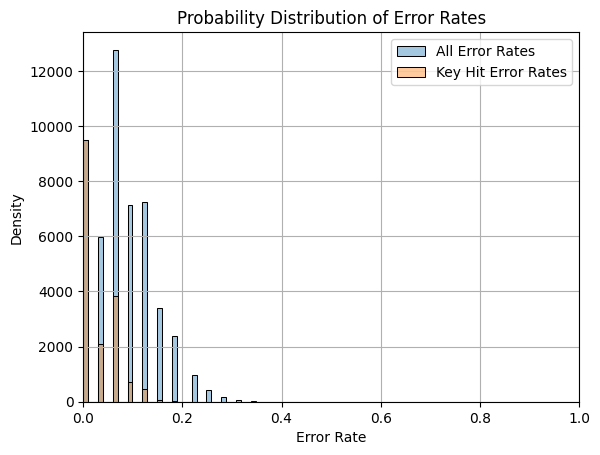

In [694]:
# Plot histogram of error rates and key hit error rates
# Plot probability distribution of error rates (density) with smoothed curves
import matplotlib.pyplot as plt
import seaborn as sns

data_all = np.asarray(gathered_results['error_rate'])
data_key = np.asarray(gathered_results['key_hit_error_rate'])

print("Average Error Rate (All): ", np.mean(data_all))
print("Average Error Rate (Key Hit): ", np.mean(data_key))

bins = 50
# Plot histograms as density
sns.histplot(data_all, binwidth=0.01, alpha=0.4, label='All Error Rates', color='C0')
sns.histplot(data_key, binwidth=0.01, alpha=0.4, label='Key Hit Error Rates', color='C1')

plt.xlabel('Error Rate')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend()
plt.title('Probability Distribution of Error Rates')
plt.grid(True)
#plt.yscale('log')
plt.show()

[np.float64(0.932511100148002), np.float64(0.9260395725320072), np.float64(0.931672760511883), np.float64(0.9319352465047829), np.float64(0.9284116331096197), np.float64(0.9312544294826365), np.float64(0.928462709284627), np.float64(0.9270491803278689), np.float64(0.9259062776304156), np.float64(0.9300993124522536)]
Consensus Ratios:  0.07066577780159022


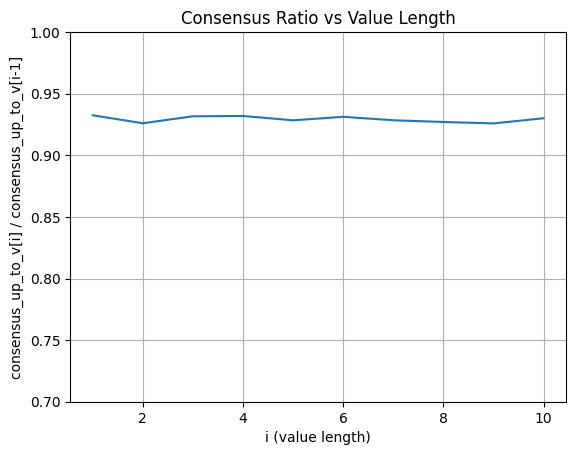

In [681]:
# Plot consensus_up_to_v[i] / consensus_up_to_v[i-1]
import matplotlib.pyplot as plt

ratios = []
for i in range(1, len(gathered_results['consensus_up_to_v'])):
    if gathered_results['consensus_up_to_v'][i-1] == 0:
        ratios.append(0)
    else:
        ratios.append(gathered_results['consensus_up_to_v'][i] / gathered_results['consensus_up_to_v'][i-1])

print(ratios)
print("Consensus Ratios: ", 1 - np.mean(ratios))
    
plt.plot(range(1, len(gathered_results['consensus_up_to_v'])), ratios)
plt.xlabel('i (value length)')
plt.ylabel('consensus_up_to_v[i] / consensus_up_to_v[i-1]')
plt.title('Consensus Ratio vs Value Length')
plt.ylim(0.7, 1)
plt.grid()
plt.show()

Quadratic fit coefficients: [0.017046  0.0334697]


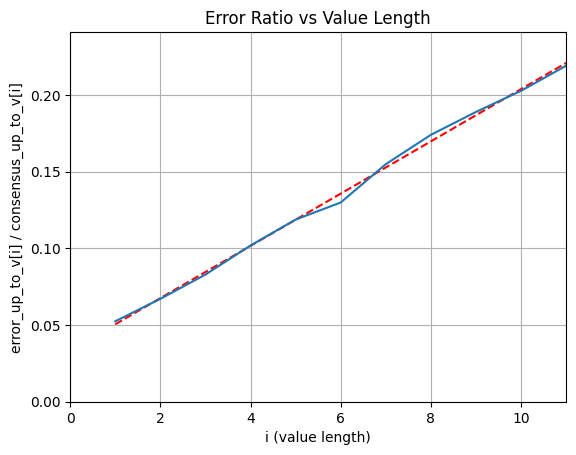

[0.05247537 0.06709626 0.08294319 0.10190567 0.11879653 0.12994718
 0.15494892 0.17409863 0.18901624 0.20280983 0.21916509]


In [695]:
# Plot error_up_to_v[i] / consensus_up_to_v[i]
error_ratios = []
for i in range(len(gathered_results['error_up_to_v'])):
    if gathered_results['consensus_up_to_v'][i] == 0:
        error_ratios.append(0)
    else:
        error_ratios.append(gathered_results['error_up_to_v'][i] / gathered_results['consensus_up_to_v'][i])
# fit a linear regression after the loop
value_take = 0
x = (np.arange(len(gathered_results['error_up_to_v'])) + 1)[value_take:]
y = np.array(error_ratios)[value_take:]
coefficients = np.polyfit(x, y, 1)
print(f'Quadratic fit coefficients: {coefficients}')
y_pred = np.polyval(coefficients, x)
plt.plot(x, y_pred, color='red', linestyle='--', label=f'Quadratic fit')
plt.plot(np.arange(len(gathered_results['error_up_to_v'])) + 1, error_ratios)
plt.xlabel('i (value length)')
plt.ylabel('error_up_to_v[i] / consensus_up_to_v[i]')
plt.title('Error Ratio vs Value Length')
plt.grid()
plt.xlim(0, np.max(x))
plt.ylim(0, np.max(error_ratios) * 1.1)
plt.show()

print(y)

In [440]:
1 / (1 + 0.05659376174018003)

0.9464375393935966

[0.         0.02649007 0.05128205 0.07453416 0.09638554 0.11695906
 0.13636364 0.15469613 0.17204301 0.18848168 0.20408163 0.21890547]


Text(0.5, 1.0, 'y vs. v')

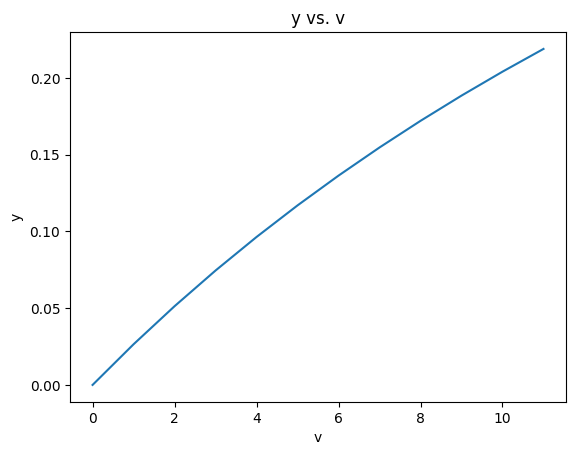

In [581]:
alpha=error_rate * mult
beta=(1 - error_rate) * mult

#alpha = 50
#beta = 950

k = 21
v = np.arange(0, 12)
y_values = v * alpha / (beta + v + k - 1)

print(y_values)

# Plot y vs. v
import matplotlib.pyplot as plt
plt.plot(v, y_values)
plt.xlabel('v')
plt.ylabel('y')
plt.title('y vs. v')


[0.97419355 0.975      0.97575758 0.97647059 0.97714286 0.97777778
 0.97837838 0.97894737 0.97948718 0.98       0.9804878 ]


Text(0.5, 1.0, 'y vs. v')

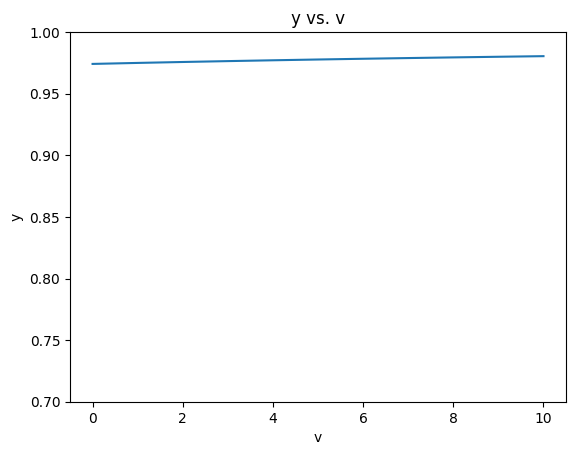

In [579]:
alpha=error_rate * mult
beta=(1 - error_rate) * mult

k = 21
v = np.arange(11)
y_values = 1 - alpha / (alpha + beta + v + k)
print(y_values)

# Plot y vs. v
import matplotlib.pyplot as plt
plt.plot(v, y_values)
plt.xlabel('v')
plt.ylabel('y')
plt.ylim(0.7, 1)
plt.title('y vs. v')


In [688]:
import pandas as pd
import numpy as np

error_df = pd.read_csv("../../output/zymo/ERR3152366.summary_consecutive_error_stats.csv")
#error_df = pd.read_csv("../../output/zymo/ERR2935851_ref.summary_consecutive_error_stats.csv")
#error_df = pd.read_csv("../../output/zymo/SRR7415629_ref.summary_consecutive_error_stats.csv")
match_df = pd.read_csv("../../output/zymo/ERR3152366.summary_consecutive_match_stats.csv")
#kmer_df = pd.read_csv("../../output/zymo/ERR2935851_ref.kmer_match.csv")

In [674]:
error_df.head()

,consecutive_error_length,count
0,1,473352372
1,2,51001182
2,3,4742204
3,4,610609
4,5,113281


(0.0, 20.0)

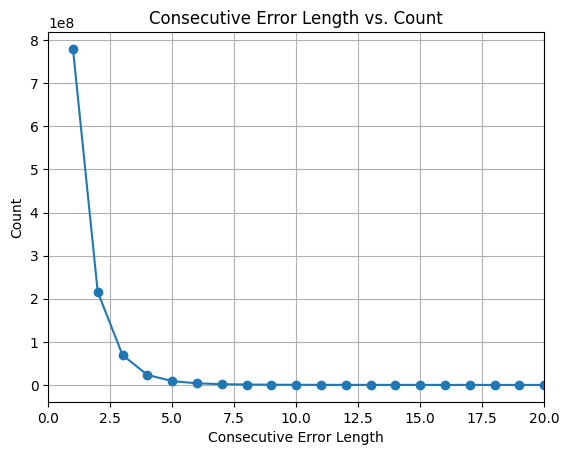

In [689]:
# Plot error_df['count'] vs. error_df['consecutive_error_length']
plt.plot(error_df['consecutive_error_length'], error_df['count'], marker='o')
plt.xlabel('Consecutive Error Length')
plt.ylabel('Count')
plt.title('Consecutive Error Length vs. Count')
plt.grid()
#plt.yscale('log')
plt.xlim(0, 20)

In [692]:
# Calculate p[010]
i = 0
error_df.iloc[i:i+1]['count'].sum() / error_df.iloc[i:]['count'].sum()

np.float64(0.7057964206562738)

In [657]:
0.7057964206562738 / 0.9529

0.7406825696886072

In [666]:
0.9612519761052346 / 0.9959

0.965209334376177

Fitted parameters: [ 0.13602738  0.         26.37853745]


/tmp/ipykernel_1272062/3309950174.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, x, y, p0=(1, 0, 0))


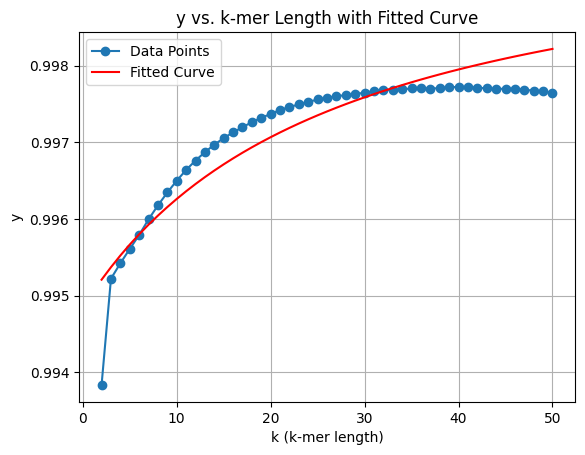

In [434]:
kmer_hit = kmer_df['num_matched_kmers']
y = kmer_hit[1:] / kmer_hit[:-1].values
#y = y * (x - 1)
x = kmer_df['k'][1:]

# Plot y vs. x and fit a linear regression
import matplotlib.pyplot as plt
plt.plot(x, y, label='Data Points', marker='o')

# fit a y = a / (x + c) + b regression
def model_func(x, a, b, c):
    return 1 - a / (x + c)
from scipy.optimize import curve_fit
popt, pcov = curve_fit(model_func, x, y, p0=(1, 0, 0))
print(f'Fitted parameters: {popt}')
y_fit = model_func(x, *popt)
plt.plot(x, y_fit, label='Fitted Curve', color='red')
plt.xlabel('k (k-mer length)')
plt.ylabel('y')
plt.title('y vs. k-mer Length with Fitted Curve')
plt.legend()
plt.grid()
plt.show()

